In [24]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Implementing kNN model for adult census income dataset

In [25]:
train_dat = pd.read_csv('drive/MyDrive/COMM075/adult_income_train_preprocessed_cleaned.csv')
test_dat = pd.read_csv('drive/MyDrive/COMM075/adult_income_test_preprocessed_cleaned.csv')

adult_Ytrain = train_dat['income_encoded']
adult_Xtrain = train_dat.drop('income_encoded',axis=1)

adult_Ytest = test_dat['income_encoded']
adult_Xtest = test_dat.drop('income_encoded',axis=1)

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score

# Choosing odd number of neighbors since there are 2 target values
knn = KNeighborsClassifier(n_neighbors=9)

scaler = StandardScaler()
adult_Xtrain_scaled = scaler.fit_transform(adult_Xtrain)
adult_Xtest_scaled = scaler.transform(adult_Xtest)

knn.fit(adult_Xtrain_scaled,adult_Ytrain)
knn_pred_adult = knn.predict(adult_Xtest_scaled)

In [27]:
knn_adult_base_accuracy = accuracy_score(adult_Ytest,knn_pred_adult)
knn_adult_base_balacc = balanced_accuracy_score(adult_Ytest,knn_pred_adult)
knn_adult_base_macrof1 = f1_score(adult_Ytest,knn_pred_adult,average='macro')
knn_adult_base_weightedf1 = f1_score(adult_Ytest,knn_pred_adult,average='weighted')
knn_adult_base_classreport = classification_report(adult_Ytest,knn_pred_adult,output_dict=True)

print(f"The accuracy of the knn classifier is {knn_adult_base_accuracy:.4f}")
print(f"The balanced accuracy of the knn classifier is {knn_adult_base_balacc:.4f}")
print(f"The Macro-F1 score of the knn classifier is {knn_adult_base_macrof1:.4f}")
print(f"The Weighted-F1 score of the knn classifier is {knn_adult_base_weightedf1:.4f}\n")
print(f"Classification report for the classifier is as below:\n {pd.DataFrame(knn_adult_base_classreport).transpose()}")

The accuracy of the knn classifier is 0.8433
The balanced accuracy of the knn classifier is 0.7661
The Macro-F1 score of the knn classifier is 0.7762
The Weighted-F1 score of the knn classifier is 0.8401

Classification report for the classifier is as below:
               precision    recall  f1-score     support
0              0.883815  0.914143  0.898723  7431.00000
1              0.693711  0.618050  0.653698  2338.00000
accuracy       0.843280  0.843280  0.843280     0.84328
macro avg      0.788763  0.766097  0.776211  9769.00000
weighted avg   0.838317  0.843280  0.840082  9769.00000


kNN-Baseline Confusion Matrix for the Adult Census Income dataset

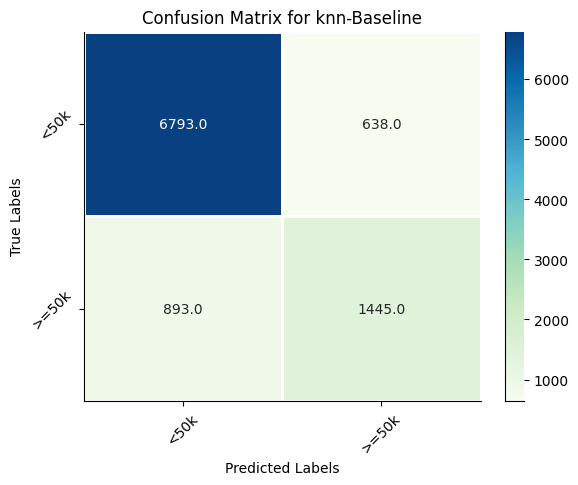

In [28]:
cm_knn = confusion_matrix(adult_Ytest,knn_pred_adult)

class_names = ['<50k','>=50k']
knn_heatmap = sns.heatmap(cm_knn,annot=True,fmt='.1f',linewidth=2,cmap='GnBu',
            xticklabels = class_names, yticklabels = class_names)

knn_heatmap.set(xlabel='Predicted Labels', ylabel='True Labels')
knn_heatmap.set_title('Confusion Matrix for knn-Baseline')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
sns.despine()

kNN-Tuned model for Adult Census Income Dataset

In [29]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

kfold = StratifiedKFold(n_splits=6, shuffle=True)

param_grid_knn = {
    'n_neighbors': [3,5,13],
    'weights':['distance'],
    'p': [1,2]
}

knn_gridsearch = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=kfold,
    pre_dispatch='2*n_jobs', # Prevents memory flooding
    verbose=4,
    scoring = 'f1_macro'
)

knn_best_adult = knn_gridsearch.fit(adult_Xtrain_scaled,adult_Ytrain)

# best_estimator_ found from GridSearchCV on sklearn's official documentation - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
best_estimator_knn_adult = knn_best_adult.best_estimator_

# Computing best predicted values for knn using the best estimator
best_ypred_knn_adult = best_estimator_knn_adult.predict(adult_Xtest_scaled)

knn_adult_tuned_accuracy = accuracy_score(adult_Ytest, best_ypred_knn_adult)
knn_adult_tuned_weightedf1 = f1_score(adult_Ytest,best_ypred_knn_adult,average='weighted')
knn_adult_tuned_balacc = balanced_accuracy_score(adult_Ytest,best_ypred_knn_adult)
knn_adult_tuned_classreport = classification_report(adult_Ytest,best_ypred_knn_adult,output_dict=True)

# Primary scoring metric used is Macro_F1
print(f'\nTuned Macro_F1 Score: {knn_best_adult.best_score_} for {knn_best_adult.best_params_}')

print(f'\nTuned Accuracy: {knn_best_adult.best_score_} for {knn_best_adult.best_params_}')
print(f'\nTuned Weighted_F1 Score: {knn_adult_tuned_weightedf1:.4f} for {knn_best_adult.best_params_}')
print(f'\nTuned Balanced Accuracy Score: {knn_adult_tuned_balacc:.4f} for {knn_best_adult.best_params_}')
print(f'\nTuned Classification Report: \n{pd.DataFrame(knn_adult_tuned_classreport).transpose().round(3)}')

Fitting 6 folds for each of 6 candidates, totalling 36 fits
[CV 1/6] END n_neighbors=3, p=1, weights=distance;, score=0.752 total time=  24.1s
[CV 2/6] END n_neighbors=3, p=1, weights=distance;, score=0.751 total time=  25.9s
[CV 3/6] END n_neighbors=3, p=1, weights=distance;, score=0.739 total time=  25.1s
[CV 4/6] END n_neighbors=3, p=1, weights=distance;, score=0.748 total time=  32.0s
[CV 5/6] END n_neighbors=3, p=1, weights=distance;, score=0.745 total time=  24.6s
[CV 6/6] END n_neighbors=3, p=1, weights=distance;, score=0.753 total time=  24.1s
[CV 1/6] END n_neighbors=3, p=2, weights=distance;, score=0.745 total time=   2.1s
[CV 2/6] END n_neighbors=3, p=2, weights=distance;, score=0.751 total time=   3.7s
[CV 3/6] END n_neighbors=3, p=2, weights=distance;, score=0.734 total time=   2.5s
[CV 4/6] END n_neighbors=3, p=2, weights=distance;, score=0.745 total time=   2.1s
[CV 5/6] END n_neighbors=3, p=2, weights=distance;, score=0.728 total time=   2.1s
[CV 6/6] END n_neighbors=3,

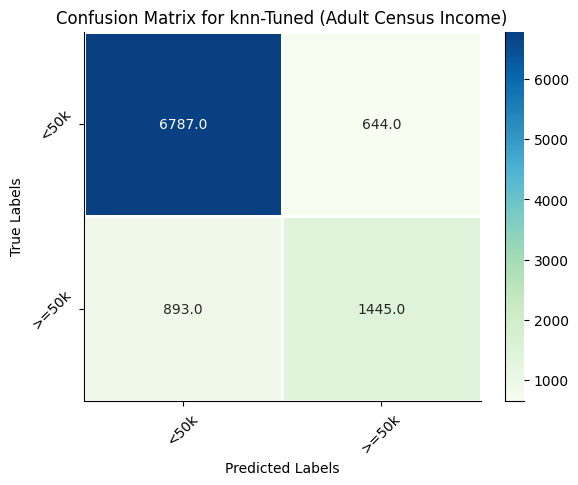

In [30]:
cm_knn_tuned = confusion_matrix(adult_Ytest,best_ypred_knn_adult)

class_names = ['<50k','>=50k']
knn_heatmap = sns.heatmap(cm_knn_tuned,annot=True,fmt='.1f',linewidth=2,cmap='GnBu',
            xticklabels = class_names, yticklabels = class_names)

knn_heatmap.set(xlabel='Predicted Labels', ylabel='True Labels')
knn_heatmap.set_title('Confusion Matrix for knn-Tuned (Adult Census Income)')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
sns.despine()

In [31]:
# Dataframe table to compare the results between kNN-Baseline and knn-Tuned for the Adult Income Dataset
knn_adult_comparison = pd.DataFrame({
    'Model': ['Baseline', 'Tuned Model'],
    'Accuracy': [knn_adult_base_accuracy, knn_adult_tuned_accuracy],
    'Balanced Accuracy': [knn_adult_base_balacc, knn_adult_tuned_balacc],
    'Macro-F1': [knn_adult_base_macrof1, knn_best_adult.best_score_],
    'Weighted-F1': [knn_adult_base_weightedf1, knn_adult_tuned_weightedf1]
})

print(knn_adult_comparison)

         Model  Accuracy  Balanced Accuracy  Macro-F1  Weighted-F1
0     Baseline  0.843280           0.766097  0.776211     0.840082
1  Tuned Model  0.842666           0.765693  0.770926     0.839537


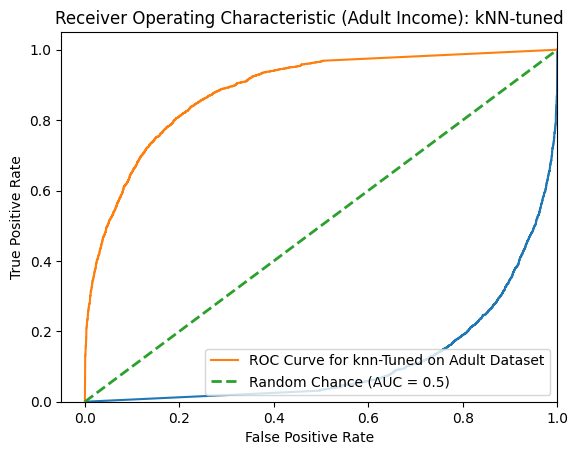

In [34]:
from sklearn.metrics import roc_curve

y_probs_adult = best_estimator_knn_adult.predict_proba(adult_Xtest_scaled)
fpr_0, tpr_0, _ = roc_curve(adult_Ytest, y_probs_adult[:,0])
fpr_1, tpr_1, _ = roc_curve(adult_Ytest, y_probs_adult[:,1])

plt.plot(fpr_0, tpr_0, label="Adult Income: <=50k")
plt.plot(fpr_1, tpr_1, label="Adult Income: >50k")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth = 2, label="Random Chance (AUC = 0.5)")
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (Adult Income): kNN-tuned")
plt.legend(loc="lower right")
plt.show()

Implementing kNN Model for IBM-HR-Attrition Dataset

In [35]:
ibm_traindat = pd.read_csv('/content/drive/MyDrive/COMM075/train_data_ibm.csv')
ibm_testdat = pd.read_csv('/content/drive/MyDrive/COMM075/test_data_ibm.csv')

ibm_Ytrain = ibm_traindat['Attrition']
ibm_Xtrain = ibm_traindat.drop('Attrition',axis=1)

ibm_Ytest = ibm_testdat['Attrition']
ibm_Xtest = ibm_testdat.drop('Attrition',axis=1)

In [36]:
# Choosing odd number of neighbors since there are 2 target values
knn = KNeighborsClassifier(n_neighbors=15)

scaler = StandardScaler()
ibm_Xtrain_scaled = scaler.fit_transform(ibm_Xtrain)
ibm_Xtest_scaled = scaler.transform(ibm_Xtest)

knn.fit(ibm_Xtrain_scaled,ibm_Ytrain)
knn_pred_ibm = knn.predict(ibm_Xtest_scaled)

In [37]:
knn_ibm_base_accuracy = accuracy_score(ibm_Ytest,knn_pred_ibm)
knn_ibm_base_balacc = balanced_accuracy_score(ibm_Ytest,knn_pred_ibm)
knn_ibm_base_macrof1 = f1_score(ibm_Ytest,knn_pred_ibm,average='macro')
knn_ibm_base_weightedf1 = f1_score(ibm_Ytest,knn_pred_ibm,average='weighted')
knn_ibm_base_classreport = classification_report(ibm_Ytest,knn_pred_ibm,output_dict=True)

print(f"The accuracy of the knn classifier is {knn_ibm_base_accuracy:.4f}")
print(f"The balanced accuracy of the knn classifier is {knn_ibm_base_balacc:.4f}")
print(f"The Macro-F1 score of the knn classifier is {knn_ibm_base_macrof1:.4f}")
print(f"The Weighted-F1 score of the knn classifier is {knn_ibm_base_weightedf1:.4f}\n")
print(f"Classification report for the classifier is as below -- \n {pd.DataFrame(knn_ibm_base_classreport).transpose().round(3)}")

The accuracy of the knn classifier is 0.8537
The balanced accuracy of the knn classifier is 0.5512
The Macro-F1 score of the knn classifier is 0.5542
The Weighted-F1 score of the knn classifier is 0.8028

Classification report for the classifier is as below -- 
               precision  recall  f1-score  support
0                 0.854   0.996     0.920  247.000
1                 0.833   0.106     0.189   47.000
accuracy          0.854   0.854     0.854    0.854
macro avg         0.844   0.551     0.554  294.000
weighted avg      0.851   0.854     0.803  294.000


Confusion Matrix: kNN-Baseline model on IBM-HR Attrition Dataset

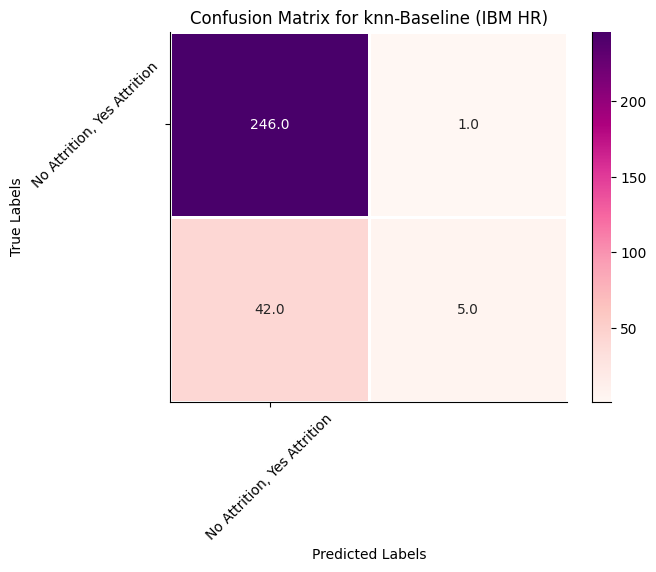

In [38]:
cm_knn = confusion_matrix(ibm_Ytest,knn_pred_ibm)

class_names = ['No Attrition', 'Yes Attrition']
knn_heatmap = sns.heatmap(cm_knn,annot=True,fmt='.1f',linewidth=2,cmap='RdPu',
            xticklabels = class_names, yticklabels = class_names)

knn_heatmap.set(xlabel='Predicted Labels', ylabel='True Labels')
knn_heatmap.set_title('Confusion Matrix for knn-Baseline (IBM HR)')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
sns.despine()

kNN-Tuned model for IBM-HR Attrition Dataset

In [39]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

kfold = StratifiedKFold(n_splits=6, shuffle=True)

param_grid_knn = {
    'n_neighbors': [3,5,13],
    'weights':['distance'],
    'p': [1,2]
}

knn_gridsearch = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=kfold,
    pre_dispatch='2*n_jobs', # Prevents memory flooding
    verbose=4,
    scoring = 'f1_macro'
)

knn_best_ibm = knn_gridsearch.fit(ibm_Xtrain_scaled,ibm_Ytrain)

# best_estimator_ found from GridSearchCV on sklearn's official documentation - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
best_estimator_knn_ibm = knn_best_ibm.best_estimator_

# Computing best predicted values for knn using the best estimator
best_ypred_knn_ibm = best_estimator_knn_ibm.predict(ibm_Xtest_scaled)

knn_ibm_tuned_accuracy = accuracy_score(ibm_Ytest, best_ypred_knn_ibm)
knn_ibm_tuned_weightedf1 = f1_score(ibm_Ytest,best_ypred_knn_ibm,average='weighted')
knn_ibm_tuned_balacc = balanced_accuracy_score(ibm_Ytest,best_ypred_knn_ibm)
knn_ibm_tuned_classreport = pd.DataFrame(classification_report(ibm_Ytest,best_ypred_knn_ibm,output_dict=True)).transpose().round(3)

# Primary scoring metric used is Macro_F1
print(f'\nTuned Macro_F1 Score: {knn_best_ibm.best_score_} for {knn_best_ibm.best_params_}')

print(f'\nTuned Accuracy: {knn_best_ibm.best_score_} for {knn_best_ibm.best_params_}')
print(f'\nTuned Weighted_F1 Score: {knn_ibm_tuned_weightedf1:.4f} for {knn_best_ibm.best_params_}')
print(f'\nTuned Balanced Accuracy Score: {knn_ibm_tuned_balacc:.4f} for {knn_best_ibm.best_params_}')
print(f'\nTuned Classification Report: \n{knn_ibm_tuned_classreport}')

Fitting 6 folds for each of 6 candidates, totalling 36 fits
[CV 1/6] END n_neighbors=3, p=1, weights=distance;, score=0.569 total time=   0.0s
[CV 2/6] END n_neighbors=3, p=1, weights=distance;, score=0.627 total time=   0.0s
[CV 3/6] END n_neighbors=3, p=1, weights=distance;, score=0.561 total time=   0.0s
[CV 4/6] END n_neighbors=3, p=1, weights=distance;, score=0.644 total time=   0.0s
[CV 5/6] END n_neighbors=3, p=1, weights=distance;, score=0.539 total time=   0.0s
[CV 6/6] END n_neighbors=3, p=1, weights=distance;, score=0.649 total time=   0.0s
[CV 1/6] END n_neighbors=3, p=2, weights=distance;, score=0.569 total time=   0.0s
[CV 2/6] END n_neighbors=3, p=2, weights=distance;, score=0.600 total time=   0.0s
[CV 3/6] END n_neighbors=3, p=2, weights=distance;, score=0.520 total time=   0.0s
[CV 4/6] END n_neighbors=3, p=2, weights=distance;, score=0.586 total time=   0.0s
[CV 5/6] END n_neighbors=3, p=2, weights=distance;, score=0.590 total time=   0.0s
[CV 6/6] END n_neighbors=3,

Confusion Matrix: kNN-Tuned model on IBM-HR Attrition Dataset

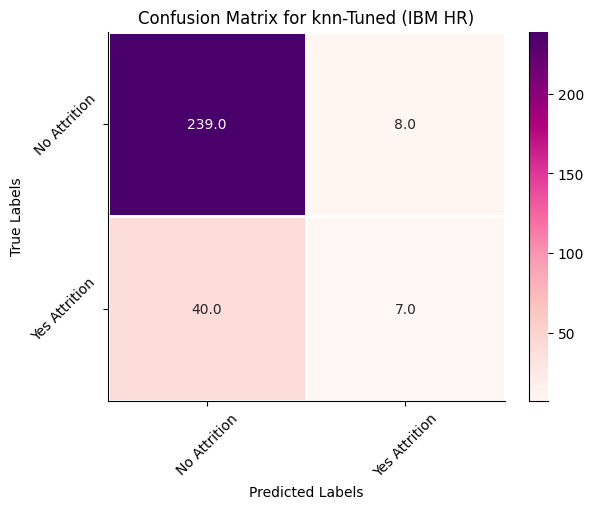

In [40]:
cm_knn = confusion_matrix(ibm_Ytest, best_ypred_knn_ibm)

class_names = ['No Attrition', 'Yes Attrition']
knn_heatmap = sns.heatmap(cm_knn,annot=True,fmt='.1f',linewidth=2,cmap='RdPu',
            xticklabels = class_names, yticklabels = class_names)

knn_heatmap.set(xlabel='Predicted Labels', ylabel='True Labels')
knn_heatmap.set_title('Confusion Matrix for knn-Tuned (IBM HR)')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
sns.despine()

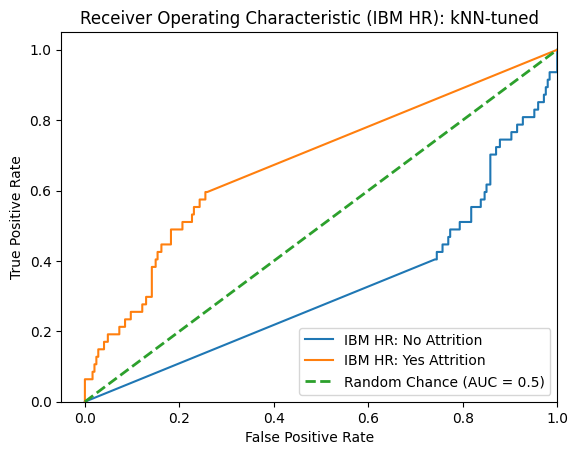

In [43]:
from sklearn.metrics import roc_curve

y_probs_ibm = best_estimator_knn_ibm.predict_proba(ibm_Xtest_scaled)
fpr_0, tpr_0, _ = roc_curve(ibm_Ytest, y_probs_ibm[:,0])
fpr_1, tpr_1, _ = roc_curve(ibm_Ytest, y_probs_ibm[:,1])

plt.plot(fpr_0, tpr_0, label="IBM HR: No Attrition")
plt.plot(fpr_1, tpr_1, label="IBM HR: Yes Attrition")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth = 2, label="Random Chance (AUC = 0.5)")
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (IBM HR): kNN-tuned")
plt.legend(loc="lower right")
plt.show()